# Read and write shapefile
This notebook shows how to load a shapefile into a networkx objet, or save a shapefile from a networkx graph object

In [1]:
import karstnet as kn
import networkx as nx

## Read .shp

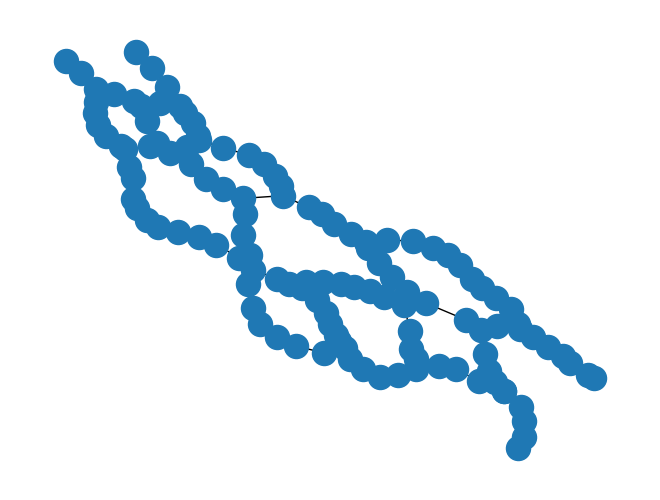

In [2]:
path_to_shapefile = r'..\data\example_shapefiles\AnastomoticPalmer.shp' 
G = kn.io_func.networkx_from_shapefile(path_to_shapefile,precision=1)
nx.draw(G,pos=kn.utils.get_pos2d(G))

## Write .shp

In [4]:
# Import the cave Migovec with the attributes 'pos' (essentiel for shapefile export) and 'flags'
H = kn.io_func.networkx_from_yaml(r'..\data\Migovec.yaml',
                                  add_node_attr=['pos','flags'],
                                  add_edge_attr=['flags'])
crs = H.graph['crs']
name = H.graph['short_name']

### Save all the nodes and edges

In [6]:
kn.io_func.networkx_to_shapefile(H,
                                crs,
                                name=name,
                                outputdir=r'..\data\test_export_examples',
                                pos_attr='pos')

### Save only the entrances as a point shapefile

In [7]:
# extract all the nodes that have a flag entrance
entrances = kn.utils.find_flagged_nodes(H,'flags','ent')
print(f'entrances: {entrances}')

entrances: [2834, 3882, 3089, 522, 1523, 1765, 3777, 4469, 4220]


In [10]:
kn.io_func.networkx_to_shapefile(H,
                                crs,
                                name=f'{name}-entrances',
                                outputdir=r'..\data\test_export_examples',
                                line=False,
                                selected_nodes= entrances,
                                pos_attr='pos')

### Save only the edges as a line shapefile

In [11]:
#extract all the edges with the flag 'add'
additional_edges = kn.utils.find_flagged_edges(H,'flags','add')
print(f'additional_edges: {additional_edges}')

additional_edges: [(2363, 3600), (2459, 1641), (6426, 2733), (6120, 6205), (6830, 6620), (6338, 6620), (4801, 2696), (7007, 2608), (2707, 256), (4377, 3895), (2980, 6222), (3280, 1863), (440, 5900), (1833, 488), (2345, 5830), (5731, 495), (2764, 504), (1894, 2747), (220, 1692), (3778, 834), (1141, 3749), (4485, 5254), (3932, 5156), (3052, 3920)]


In [13]:
crs = H.graph['crs']
name = H.graph['short_name']
kn.io_func.networkx_to_shapefile(H,
                                crs,
                                name=f'{name}-AdditionalEdges',
                                outputdir='../data/test_export_examples',
                                point=False,
                                selected_edges = additional_edges,
                                pos_attr='pos')